<a href="https://colab.research.google.com/github/jaredlan1/getting_started_with_ML/blob/main/Exam1_question_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(0)

In [46]:
# training data
nt = 30
xtrain = torch.zeros(nt, 1)
xtrain[0] = 0.5
for i in range(1, nt):
        xtrain[i] = 3.7*xtrain[i-1]*(1 - xtrain[i-1])

print(xtrain)

tensor([[0.5000],
        [0.9250],
        [0.2567],
        [0.7060],
        [0.7681],
        [0.6591],
        [0.8313],
        [0.5189],
        [0.9237],
        [0.2608],
        [0.7134],
        [0.7565],
        [0.6815],
        [0.8031],
        [0.5850],
        [0.8982],
        [0.3382],
        [0.8281],
        [0.5267],
        [0.9224],
        [0.2649],
        [0.7206],
        [0.7450],
        [0.7029],
        [0.7727],
        [0.6499],
        [0.8419],
        [0.4925],
        [0.9248],
        [0.2573]])


In [47]:
x_T = xtrain[:-1]
print(x_T)
x_Tp1 = xtrain[1:]
print(x_Tp1)

tensor([[0.5000],
        [0.9250],
        [0.2567],
        [0.7060],
        [0.7681],
        [0.6591],
        [0.8313],
        [0.5189],
        [0.9237],
        [0.2608],
        [0.7134],
        [0.7565],
        [0.6815],
        [0.8031],
        [0.5850],
        [0.8982],
        [0.3382],
        [0.8281],
        [0.5267],
        [0.9224],
        [0.2649],
        [0.7206],
        [0.7450],
        [0.7029],
        [0.7727],
        [0.6499],
        [0.8419],
        [0.4925],
        [0.9248]])
tensor([[0.9250],
        [0.2567],
        [0.7060],
        [0.7681],
        [0.6591],
        [0.8313],
        [0.5189],
        [0.9237],
        [0.2608],
        [0.7134],
        [0.7565],
        [0.6815],
        [0.8031],
        [0.5850],
        [0.8982],
        [0.3382],
        [0.8281],
        [0.5267],
        [0.9224],
        [0.2649],
        [0.7206],
        [0.7450],
        [0.7029],
        [0.7727],
        [0.6499],
        [0.8419],
        [

In [48]:
nz=3

class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(1,10),
        nn.Tanh(),
        nn.Linear(10,nz))
  def forward(self, x):
      return self.net(x)

class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.net=nn.Sequential(
        nn.Linear(nz,10),
        nn.Tanh(),
        nn.Linear(10,1)

    )

  def forward(self, z):
      return self.net(z)

In [49]:
encoder = Encoder()
decodre = Decoder()

In [50]:
K = nn.Parameter(torch.rand(nz, nz)*0.1)
params = list(encoder.parameters()) + list(decodre.parameters())+[K]
opt = torch.optim.Adam(params, lr=1e-3)

epocs = 10000
loss_array = []

for epocs in range(epocs):
  opt.zero_grad()
  z_all = encoder(xtrain)
  z_t=z_all[:-1]
  z_tp1=z_all[1:]

  z_pred = z_t@K.T

  x_rec=decodre(z_all)
  x_pred=decodre(z_pred)

  loss_recon=torch.mean((x_rec-xtrain)**2)
  loss_latentspace = torch.mean((z_pred-z_tp1)**2)
  loss_predicton= torch.mean((x_pred-x_Tp1)**2)

  z_mean= torch.mean(z_all, dim=1)
  z_std=torch.std(z_all,dim=1,unbiased=False)
  loss_norm=torch.mean(z_mean**2)+torch.mean((z_std-1.0)**2)

  loss = loss_recon+loss_latentspace +loss_predicton +loss_norm
  loss.backward()
  opt.step()
  loss_array.append(loss.item())


In [51]:
with torch.no_grad():
    z0 = encoder(xtrain[0:1])
    z_roll = [z0]
    for _ in range (nt-1):
        z_next = z_roll[-1]@K.T
        z_roll.append(z_next)

    z_roll=torch.cat(z_roll,dim=0)
    x_roll=decodre(z_roll)

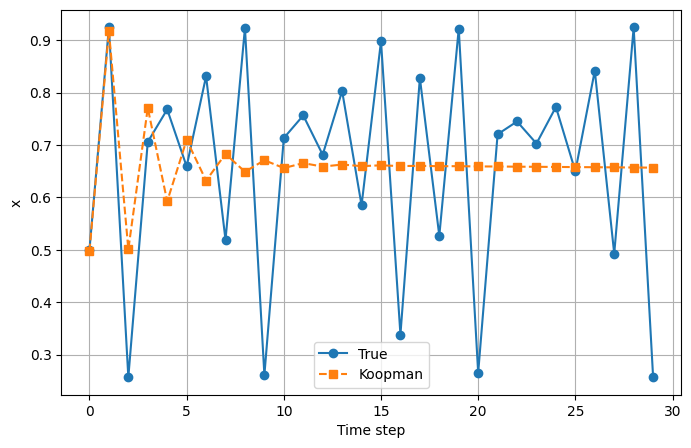

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(range(nt), xtrain.numpy(), 'o-', label='True')
plt.plot(range(nt), x_roll.numpy(), 's--', label='Koopman')
plt.xlabel('Time step')
plt.ylabel('x')

plt.legend()
plt.grid(True)
plt.show()


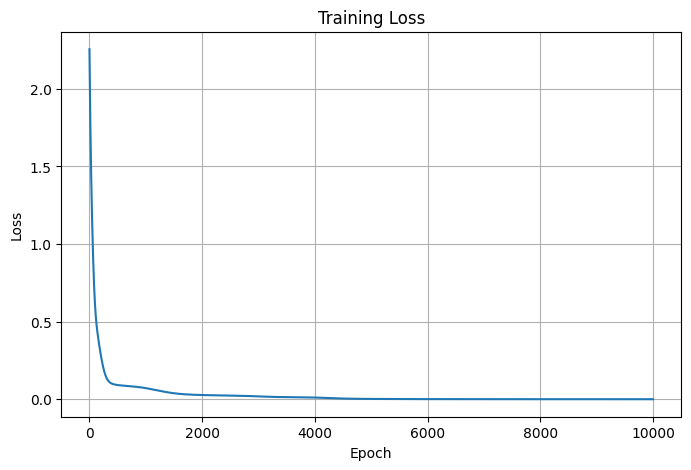

In [53]:
plt.figure(figsize=(8, 5))
plt.plot(loss_array)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.show()

In [56]:
eigvals = torch.linalg.eigvals(K)

print(" eigenvalues:")
print(eigvals)

 eigenvalues:
tensor([ 0.9998+0.j,  0.0421+0.j, -0.6595+0.j], grad_fn=<LinalgEigBackward0>)
